In [33]:
import math
import airfrans as af
import torch
import torch.nn.functional as F
from torch import nn
from enf.steerable_attention.equivariant_cross_attention_nef import EquivariantCrossAttentionNeF
from enf.steerable_attention.equivariant_cross_attention import RelativePositionND
import os
import math
import json
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch_geometric.loader import DataLoader
from utils.dataset import SDFDataset
from utils.meta_learning import inner_loop
import hydra
from omegaconf import DictConfig, OmegaConf
import wandb
import datetime
import matplotlib.pyplot as plt

@torch.no_grad()
def latent_influence(nef, coords, p, c, g, device):
    # coords : [1, C, D]  – query points for one sample
    # p      : [1, Z, D]  – latent positions
    # c      : [1, Z, H]  – latent codes
    # g      : [1, Z, 1]  – σ
    _, att = nef(coords.to(device),
                 p.to(device),
                 c.to(device),
                 g.to(device),
                 return_attn=True)          # att  [1,C,Z,H]
    # average over query points and heads → [Z]
    infl = att.mean(dim=(1, 3)).squeeze(0).cpu()    # softmax already ∈[0,1]
    return infl    

def plot_latent_influence(p_xy, influence, title="Latent attention"):
    
    plt.figure(figsize=(4,4))
    sc = plt.scatter(p_xy[:,0], p_xy[:,1],
                     c=influence, s=120, cmap='viridis', edgecolors='k')
    plt.colorbar(sc, label='avg attention weight')
    plt.axis('equal'); plt.title(title); plt.show()
 
# ──────────────────────────────────────────────────────────────────────────────
#  helper: draw attention maps for every latent in the final cross-attention
# ──────────────────────────────────────────────────────────────────────────────
import math, matplotlib.pyplot as plt
import torch

def show_latent_attention_maps(
    nef, coords, p, c, g, device,
    n_cols: int = 4, cmap: str = "magma",
    point_size: int = 8,
):
    """
    Parameters
    ----------
    nef      : the trained EquivariantCrossAttentionNeF (in .eval() mode)
    coords   : [1, C, D] query points
    p, c, g  : latents from `inner_loop`
    device   : torch.device
    n_cols   : how many columns in the subplot grid
    cmap     : matplotlib colour-map for the weights
    point_size : scatter dot size
    """

    # 1) pull the attention tensor  att ∈ [1, C, Z, heads]
    with torch.no_grad():
        _, att = nef(coords.to(device),
                     p.to(device), c.to(device), g.to(device),
                     return_attn=True)           # requires the small patch

    # 2) collapse across heads  →  [C, Z]  (and move to CPU numpy)
    att_cz = att.mean(dim=3).squeeze(0).cpu()

    Z   = att_cz.shape[1]
    xy  = coords.squeeze(0).cpu()[:, :2]         # [C, 2] for plotting
    pxy = p.squeeze(0).cpu()[:, :2]              # latent positions

    # 3) figure layout
    n_rows = math.ceil(Z / n_cols)
    fig, axs = plt.subplots(n_rows, n_cols,
                            figsize=(4 * n_cols, 4 * n_rows),
                            squeeze=False)

    v_max = att_cz.max().item()
    for z in range(Z):
        ax = axs[z // n_cols][z % n_cols]
        w  = att_cz[:, z]                        # length-C vector

        sc = ax.scatter(xy[:, 0], xy[:, 1],
                        c=w, s=point_size, cmap=cmap,
                        vmin=0.0, vmax=v_max)
        ax.scatter(pxy[z, 0], pxy[z, 1],
                   marker="x", color="cyan", s=60, linewidths=2)

        ax.set_aspect("equal")
        ax.set_title(f"latent {z}")
        ax.axis("off")

    # colour-bar (one for the whole figure)
    cbar = fig.colorbar(sc, ax=axs.ravel().tolist(),
                        fraction=0.015, pad=0.01)
    cbar.set_label("attention weight", rotation=90)

    plt.tight_layout()
    plt.show()

import math, matplotlib.pyplot as plt, torch

def show_latent_attention_per_head(
    nef,
    coords, p, c, g,                          # tensors from inner_loop
    latent_idx: int,                          # which latent to visualise
    device,
    cmap: str = "magma",
    point_size: int = 10,
):
    """
    Draws H sub-plots (one per attention head) showing how strongly the
    chosen latent attends to each query point.
    """
    # 1) pull full attention tensor  [1, C, Z, H]
    with torch.no_grad():
        _, att = nef(coords.to(device),
                     p.to(device), c.to(device), g.to(device),
                     return_attn=True)

    # slice out the latent, bring to cpu  -> [C, H]
    att_latent = att.squeeze(0)[:, latent_idx].cpu()
    heads = att_latent.shape[1]

    xy   = coords.squeeze(0).cpu()[:, :2]         # [C, 2] for plotting
    p_xy = p.squeeze(0)[latent_idx, :2].cpu()     # latent position

    n_cols = 2
    n_rows = math.ceil(heads / n_cols)
    fig, axs = plt.subplots(n_rows, n_cols,
                            figsize=(4*n_cols, 4*n_rows),
                            squeeze=False)
    v_max = att_latent.max().item()

    for h in range(heads):
        ax = axs[h // n_cols][h % n_cols]
        w  = att_latent[:, h]
        sc = ax.scatter(xy[:, 0], xy[:, 1],
                        c=w, s=point_size, cmap=cmap,
                        vmin=0.0, vmax=v_max)
        ax.scatter(p_xy[0], p_xy[1],
                   marker="x", color="cyan",
                   s=60, linewidths=2)
        ax.set_title(f"latent {latent_idx}  ·  head {h}")
        ax.set_aspect("equal"); ax.axis("off")

    # colour-bar for whole figure
    cbar = fig.colorbar(sc, ax=axs.ravel().tolist(),
                        fraction=0.015, pad=0.01)
    cbar.set_label("attention weight")
    plt.show()
    



In [2]:
import yaml
CFG_PATH  = "/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/config_airfrans.yaml"
cfg   = OmegaConf.create(yaml.safe_load(open(CFG_PATH)))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Config loaded ✓   Device →", device)

Config loaded ✓   Device → cpu


Loading dataset (task: full, split: train):   0%|          | 0/15 [00:00<?, ?it/s]

Loading dataset (task: full, split: test): 100%|██████████| 12/12 [00:04<00:00,  2.73it/s]


Computing normalization parameters from training data...

Normalization parameters computed:
Target mean: [0.2324]
Target std: [0.4761]
Processing dataset...
Using provided normalization parameters...
Processing dataset...


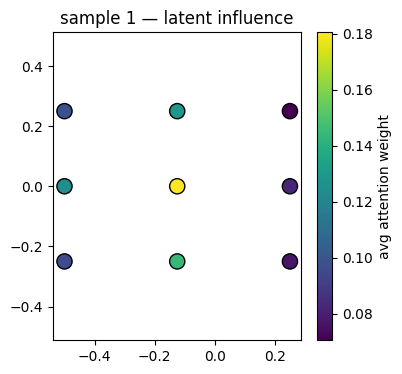

/tmp/ipykernel_123373/2838449777.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


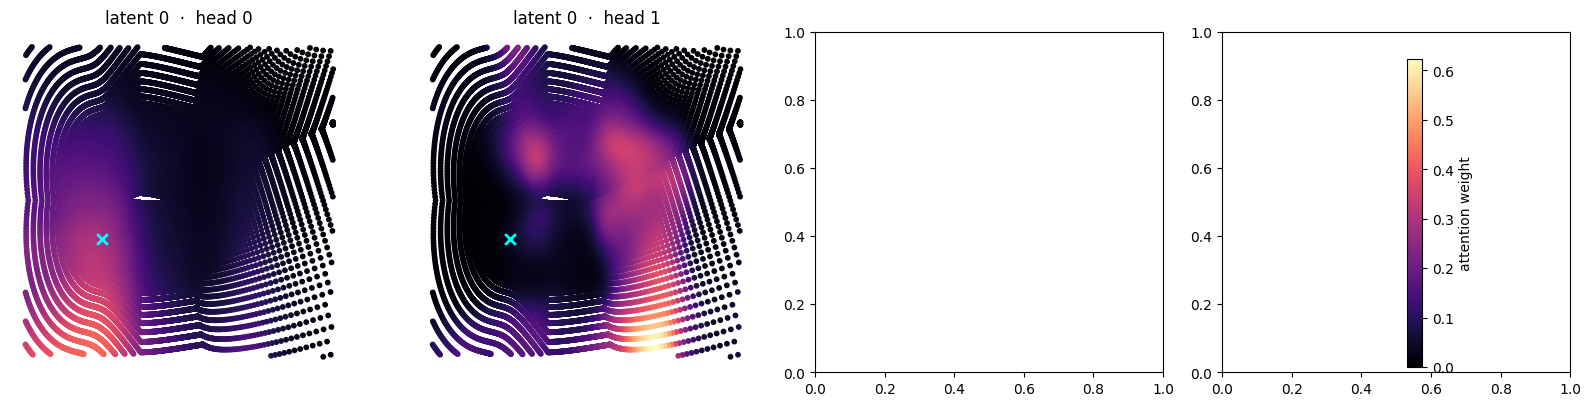

In [23]:

batch_size    = cfg.optim.batch_size
epochs        = cfg.optim.epochs
inner_steps   = cfg.optim.inner_steps
lr_enf        = cfg.optim.lr_enf
lr_latents    = cfg.optim.lr_latents
num_points    = cfg.optim.num_points
coord_dim     = cfg.model.coord_dim       # e.g. 2
out_dim       = cfg.model.num_out    # e.g. 1

# 2) Build ENF backbone
enf = EquivariantCrossAttentionNeF(
    num_hidden=cfg.model.num_hidden,
    num_heads=cfg.model.num_heads,
    num_layers=cfg.model.num_layers,
    num_out=out_dim,
    latent_dim=cfg.model.latent_dim,
    cross_attn_invariant=RelativePositionND(coord_dim),
    self_attn_invariant=RelativePositionND(coord_dim),
    embedding_freq_multiplier=(cfg.model.emb_freq_q, cfg.model.emb_freq_v),
    condition_value_transform=True,
    use_gaussian_window=True,
    use_enhanced_stem=cfg.model.use_enhanced_stem,
).to(device)
checkpoint_path = '/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/experiments/training/2025-05-31_17-41-48/checkpoints/best_enf.pt'
index = 1
ckpt = torch.load(checkpoint_path, map_location=device)
enf.load_state_dict(ckpt["model_state"])

# Inner lr for latent features (positions and window frozen)
alpha_c = ckpt["alpha_c"].to(device)  

# Build datasets
train_raw, train_names = af.dataset.load(cfg.dataset.root_path, cfg.dataset.task, train=True)
val_raw,   val_names   = af.dataset.load(cfg.dataset.root_path, cfg.dataset.task, train=False)

train_ds = SDFDataset(train_raw, train_names, is_train=True, num_points=None)
val_ds   = SDFDataset(val_raw,   val_names,   is_train=False, coef_norm=train_ds.coef_norm, num_points=None)

data = val_ds.processed_dataset[index]
C = data.input.size(0)           # points per sample

# 4) prepare tensors and run inner-loop (same as training)
coords = data.input.view(1, C, -1).to(device)
sdf    = data.output.view(1, C, -1).to(device)
enf.to(device)  # move enf to device
enf.eval()  # set enf to eval mode
# inner_loop returns (out, img_sub, (p, c, g))
_, _, (p, c, g) = inner_loop(enf, cfg, coords, sdf, alpha_c, is_train=False)

# 5) compute latent importance
scores = latent_influence(enf, coords, p, c, g, device)

# 6) visualise
plot_latent_influence(p.squeeze(0).cpu(), scores,
                f"sample {index} — latent influence")
   
## ------------------------------------------------------------------
#  generate per-head attention maps for latent `ℓ`
latent_to_inspect = 0          # choose any 0 … Z-1
show_latent_attention_per_head(
    enf, coords, p, c, g,
    latent_idx=latent_to_inspect,
    device=device)





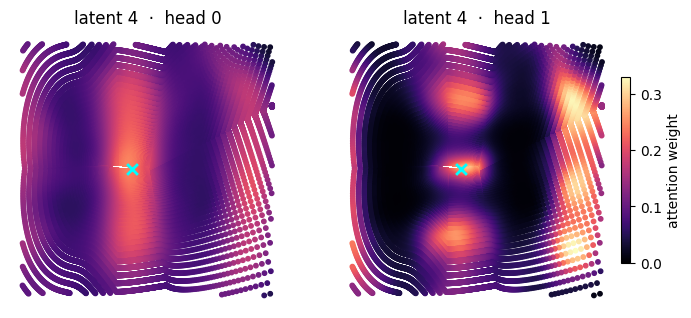

In [38]:
#  generate per-head attention maps for latent `ℓ`
latent_to_inspect = 4         # choose any 0 … Z-
show_latent_attention_per_head(
    enf, coords, p, c, g,
    latent_idx=latent_to_inspect,
    device=device)

/tmp/ipykernel_123373/305151496.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


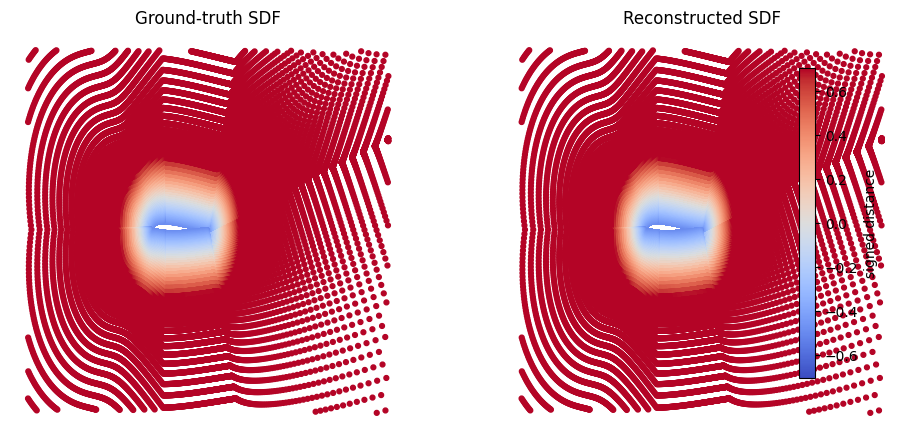

In [28]:
# ------------------------------------------------------------------
#  compare predicted vs. true SDF
out, att = enf(coords.to(device),
                     p.to(device), c.to(device), g.to(device),
                     return_attn=True)

sdf = data.output.view(1, C, -1).to(device)
def plot_sdf_reconstruction(coords, sdf_true, sdf_pred,cmap="coolwarm", point_size=12):
        """
        coords:   [1, C, D]
        sdf_true: [1, C, 1]
        sdf_pred: [1, C, 1]
        """
        xy   = coords.squeeze(0).cpu()[:, :2]         # [C,2]
        s_gt = sdf_true.squeeze(0).cpu().flatten()    # [C]
        s_pr = sdf_pred.squeeze(0).cpu().flatten()    # [C]

        v_max = max(s_gt.abs().max(), s_pr.abs().max()).item()/10

        fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))

        sc0 = axs[0].scatter(xy[:,0], xy[:,1], c=s_gt,
                            cmap=cmap, s=point_size,
                            vmin=-v_max, vmax=v_max)
        axs[0].set_title("Ground-truth SDF")
        axs[0].set_aspect("equal"); axs[0].axis("off")

        sc1 = axs[1].scatter(xy[:,0], xy[:,1], c=s_pr,
                            cmap=cmap, s=point_size,
                            vmin=-v_max, vmax=v_max)
        axs[1].set_title("Reconstructed SDF")
        axs[1].set_aspect("equal"); axs[1].axis("off")

        fig.colorbar(sc1, ax=axs.ravel().tolist(),
                    fraction=0.02, pad=0.01,
                    label="signed distance")
        plt.tight_layout(); plt.show()

plot_sdf_reconstruction(coords, sdf, out.detach())

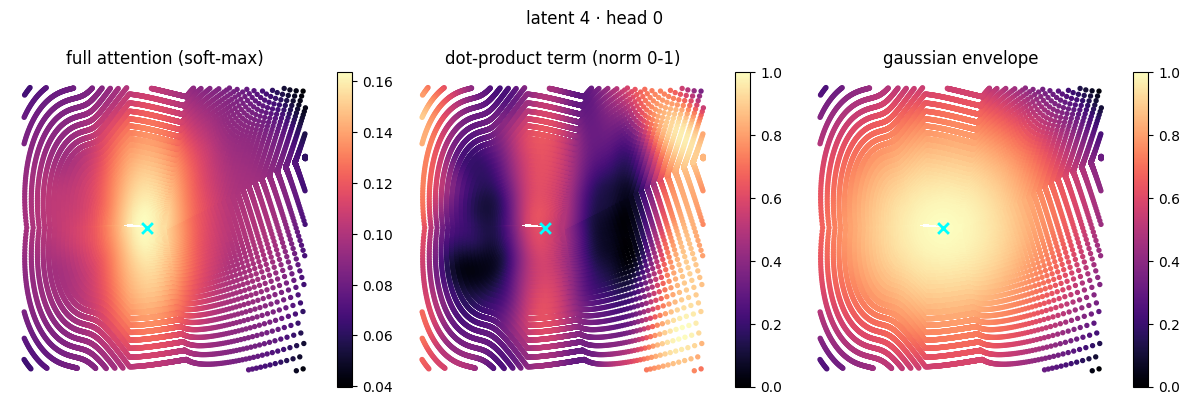

In [47]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  Attention-component debugger  (patched: embed 'c' through latent_stem)   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
def attention_breakdown(enf, coords, p, c, g, device):
    """
    Returns:
      att      : [C, Z, H]   soft-max weights
      logits   : [C, Z, H]   full logits  (q·k  –  d²/σ²)
      dp_term  : [C, Z, H]   dot-product only
      gauss    : [C, Z]      gaussian term  (same for all heads)
      xy       : [C, 2]      query positions
    """
    att_mod = enf.cross_blocks[0].attn
    H       = att_mod.num_heads
    B, C, D = coords.shape
    Z       = p.size(1)

    # ── device copies ────────────────────────────────────────────────────────
    x   = coords.to(device)                 # [B,C,D]
    pl  = p.to(device)                      # [B,Z,D]
    gs  = g.to(device)                      # [B,Z,1]

    # (1) invariant & queries
    inv     = att_mod.invariant(x, pl)                     # [B,C,Z,D]
    inv_q   = att_mod.invariant_embedding_query(inv)       # [B,C,Z,Hid]
    q       = (att_mod.inv_emb_to_q(inv_q)
               .view(B, C, Z, H, -1))                      # [B,C,Z,H,hid]

    # (2) **embed latent codes**
    c_hid = enf.latent_stem(c.to(device))                  # [B,Z,Hid]

    k_flat = att_mod.a_to_k(c_hid)                         # [B,Z,H*hid]
    k      = k_flat.view(B, Z, H, -1)                      # [B,Z,H,hid]
    k_b    = k.unsqueeze(1).expand(-1, C, -1, -1, -1)      # [B,C,Z,H,hid]

    # dot-product term
    dp = (q * k_b).sum(-1) * att_mod.scale                 # [B,C,Z,H]

    # gaussian term
    d2     = ((pl.unsqueeze(1) - x.unsqueeze(2))**2).sum(-1, keepdim=True)
    gauss  = -d2 / (gs.unsqueeze(1)**2)                    # [B,C,Z,1]
    gaussE = gauss.expand(-1, -1, -1, H)                   # [B,C,Z,H]

    logits = dp + gaussE
    att    = torch.softmax(logits, dim=2)                  # over Z

    return (att.squeeze(0).cpu(),
            logits.squeeze(0).cpu(),
            dp.squeeze(0).cpu(),
            gauss.squeeze(0).squeeze(-1).cpu(),
            coords.squeeze(0).cpu()[:, :2])
latent_id = 4      # choose 0 … Z-1
head_id   = 0     # choose 0 … H-1

att, logits, dp, gauss, xy = attention_breakdown(enf, coords, p, c, g, device)
p_xy = p.squeeze(0)[latent_id, :2].cpu()

plot_components(latent_id, head_id,
                att.detach(), logits.detach(), dp.detach(), gauss,
                xy, p_xy)


In [1]:
import torch
import numpy as np
import airfrans as af
from utils.dataset import AirfransFlowDataset
root_path = "/scratch/dmsm/gi.catalani/Airfrans/Dataset/"
task='full'
train_data, train_names = af.dataset.load(root=root_path, task=task, train=True)
test_data, test_names = af.dataset.load(root=root_path, task=task, train=False)


/scratch/dmsm/gi.catalani/conda/envs/py311_gdl/lib/python3.11/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.27' not found (required by /mnt/scratch/dmsm/gi.catalani/conda/envs/py311_gdl/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/scratch/dmsm/gi.catalani/conda/envs/py311_gdl/lib/python3.11/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.27' not found (required by /mnt/scratch/dmsm/gi.catalani/conda/envs/py311_gdl/lib/python3.11/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
Loading dataset (task: full, split: test): 100%|██████████| 200/200 [03:02<00:00,  1.10it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/experiments/training/training_result_20250610-223546/best_model_predictions.npz.npy'

In [2]:
import torch
from torch_geometric.data import Data
from tqdm import tqdm
import copy


target_field_out = 'pressure'
class AirfransDataset:
    def __init__(self, data_list, data_names, target_field='implicit_distance', is_train=True, coef_norm=None, num_points=None):
        """
        Initialize the SDFDataset class with pre-loaded data.
        
        Args:
            data_list: list of np.arrays containing the raw data
            data_names: list of data names
            target_field: str, one of ['velocity', 'pressure', 'turbulent_viscosity', 'implicit_distance', 'all_outputs']
            is_train: bool, whether this is training data (to compute normalization)
            coef_norm: dict, normalization coefficients (required if is_train=False)
            num_points: int, number of points to subsample (if None, use all points)
        """
        self.data_list = copy.deepcopy(data_list)
        self.data_names = data_names
        self.target_field = target_field
        self.num_points = num_points
        self.is_train = is_train
        
        if is_train:
            print("Computing normalization parameters from training data...")
            self.compute_norm_params(data_list)
        else:
            if coef_norm is None:
                raise ValueError("coef_norm must be provided when is_train=False")
            print("Using provided normalization parameters...")
            self.coef_norm = coef_norm
            self.pos_norm = coef_norm['pos_norm']
            self.inlet_norm = coef_norm['inlet_norm']
            self.implicit_norm = coef_norm['implicit_norm']

        print("Processing dataset...")
        self.processed_dataset = self.process_data(data_list)

    def compute_norm_params(self, data_list):
        """Compute normalization parameters."""
        self.coef_norm = {}
        
        # Define target indices based on field
        target_indices = {
            'all_outputs': slice(7, 11),
            'velocity': slice(7, 9),
            'pressure': 9,
            'turbulent_viscosity': 10,
            'implicit_distance': 4
        }
        target_idx = target_indices[self.target_field]
        
        # Gather all target values
        if isinstance(target_idx, slice):
            all_targets = np.concatenate([data[:, target_idx] for data in data_list])
        else:
            all_targets = np.concatenate([data[:, target_idx:target_idx+1] for data in data_list])
        
        self.coef_norm['mean'] = all_targets.mean(axis=0)
        self.coef_norm['std'] = all_targets.std(axis=0)
        
        # Calculate position normalization
        all_positions = np.concatenate([data[:, :2] for data in data_list])
        self.pos_norm = {
            'min': all_positions.min(axis=0),
            'max': all_positions.max(axis=0)
        }
        self.coef_norm['pos_norm'] = self.pos_norm
        
        # Calculate inlet velocity normalization
        all_inlet_vel = np.concatenate([data[:, 2:4] for data in data_list])
        self.inlet_norm = {
            'min': all_inlet_vel.min(axis=0),
            'max': all_inlet_vel.max(axis=0)
        }
        self.coef_norm['inlet_norm'] = self.inlet_norm
        
        # Calculate implicit distance normalization
        all_implicit = np.concatenate([data[:, 4:5] for data in data_list])
        self.implicit_norm = {
            'min': all_implicit.min(axis=0),
            'max': all_implicit.max(axis=0)
        }
        self.coef_norm['implicit_norm'] = self.implicit_norm
        
        print("\nNormalization parameters computed:")
        print(f"Target mean: {np.array2string(self.coef_norm['mean'], precision=4, separator=', ')}")
        print(f"Target std: {np.array2string(self.coef_norm['std'], precision=4, separator=', ')}")
        return self.coef_norm

    def process_data(self, dataset_list):
        """Process the raw data into the required format using global normalization."""
        dataset = []
        
        target_indices = {
            'all_outputs': slice(7, 11),
            'velocity': slice(7, 9),
            'pressure': 9,
            'turbulent_viscosity': 10,
            'implicit_distance': 4
        }
        target_idx = target_indices[self.target_field]
        
        # Process each simulation
        for i, sim_data in enumerate(dataset_list):
            if self.data_names[i] == 'airFoil2D_SST_50.077_-4.416_2.834_4.029_1.0_5.156':
                print("Skipping sample airFoil2D_SST_50.077_-4.416_2.834_4.029_1.0_5.156")
                continue
                
            # Extract and normalize positions
            pos = sim_data[:, :2]
            pos = 2 * (pos - self.pos_norm['min']) / (self.pos_norm['max'] - self.pos_norm['min']) - 1
            
            # Extract and normalize inlet velocity
            inlet_vel = sim_data[:, 2:4]
            inlet_vel_norm = 2 * (inlet_vel - self.inlet_norm['min']) / (self.inlet_norm['max'] - self.inlet_norm['min']) - 1
            
            # Extract normals
            normals = sim_data[:, 5:7]
            
            # Prepare input data based on target field
            if self.target_field in ['pressure', 'turbulent_viscosity', 'velocity', 'all_outputs']:
                # Include normalized implicit distance for these fields
                implicit_dist = sim_data[:, 4:5]
                implicit_dist_norm = 2 * (implicit_dist - self.implicit_norm['min']) / (self.implicit_norm['max'] - self.implicit_norm['min']) - 1
                input_data = np.concatenate([pos, implicit_dist_norm], axis=1)
            else:
                input_data = pos
            
            # Extract and normalize target data
            if isinstance(target_idx, slice):
                output = sim_data[:, target_idx]
            else:
                output = sim_data[:, target_idx:target_idx+1]
            
            # Normalize target using mean and std
            output = (output - self.coef_norm['mean']) / self.coef_norm['std']
            
            # Create conditional input (mean inlet velocity)
            cond = np.mean(inlet_vel_norm, axis=0, keepdims=True)
            
            # Create PyG Data entry
            data_entry = Data(
                pos=torch.tensor(pos, dtype=torch.float),
                input=torch.tensor(input_data, dtype=torch.float),
                output=torch.tensor(output, dtype=torch.float),
                cond=torch.tensor(cond, dtype=torch.float),
                is_airfoil=torch.tensor(sim_data[:, -1]),
                normals=torch.tensor(normals, dtype=torch.float)
            )
            
            dataset.append(data_entry)
        
        # Subsample if requested
        if self.num_points is not None:
            dataset = self.subsample_dataset(dataset, self.num_points)
            
        return dataset

# Load dataset
train_dataset_out_obj = AirfransDataset(train_data, train_names,target_field=target_field_out, is_train=True)
coef_norm_out = train_dataset_out_obj.coef_norm
train_dataset_out = train_dataset_out_obj.processed_dataset
val_dataset_out = AirfransDataset(test_data, test_names, target_field=target_field_out, is_train=False, coef_norm=coef_norm_out).processed_dataset
prediction_file_coral = '/home/dmsm/gi.catalani/Projects/ENF/baselines/training_airfrans_20241223_220009/results_test.pth'
data_coral = torch.load(prediction_file_coral)
prediction_file_enf = '/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/airfrans/experiments/training/training_result_20250618-175419/best_model_predictions.npz.npy'
data_enf = np.load(prediction_file_enf,allow_pickle=True).item()

Computing normalization parameters from training data...

Normalization parameters computed:
Target mean: [-452.1169]
Target std: [2946.9662]
Processing dataset...
Skipping sample airFoil2D_SST_50.077_-4.416_2.834_4.029_1.0_5.156
Using provided normalization parameters...
Processing dataset...


In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import scienceplots
import os
from scipy.spatial import cKDTree
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

def plot_comparison(idx, data_coral, data_enf, val_dataset, save_dir):
    plt.style.use(['science', 'no-latex'])
    plt.rcParams.update({
        'axes.linewidth': 2,
        'lines.linewidth': 2,
        'axes.labelsize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'axes.titlesize': 'large'
    })
    # Constants
    rho = 1.225
    chord = 1
    mean = -452.116
    std = 2946.966
    # CORAL
    Ux = test_data[idx][0, 2]
    Uy = test_data[idx][0, 3]
    U = np.sqrt(Ux**2 + Uy**2)
    alpha = np.arctan2(Uy, Ux) * 180 / np.pi

    # Get data for ENF model (using ENF coordinates)
    enf_pred = data_enf['predictions'][idx][:, 0] * std + mean

    # Get data for CORAL model using validation dataset
    sample = val_dataset[idx]
    coral_coords = sample.pos.numpy()
    coral_pred = data_coral['predictions'][idx][:, 0] * std + mean
    coral_target = sample.output.numpy().squeeze() * std + mean
    is_airfoil = sample.is_airfoil.numpy()
    normals = sample.normals.numpy()

    # Process airfoil surface for plotting (for contour fill)
    nodes_surf = coral_coords[is_airfoil.astype(bool)]
    normals_surface = normals[is_airfoil.astype(bool)]
    upper_nodes = nodes_surf[normals_surface[:, 1] < 0]
    lower_nodes = nodes_surf[normals_surface[:, 1] > 0]

    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(24, 10))

    # Calculate global min/max for consistent color scales
    vmin = min(enf_pred.min(), coral_pred.min(), coral_target.min())/10**3
    vmax = max(enf_pred.max(), coral_pred.max(), coral_target.max())/10**3
    
    # Calculate errors
    error_enf = np.abs(enf_pred - coral_target)
    error_coral = np.abs(coral_pred - coral_target)
    
    # For error visualization, use a better approach:
    # Use percentiles to avoid outliers dominating the colormap
    all_errors = np.concatenate([error_enf, error_coral])
    error_vmin = 0
    error_vmax = np.percentile(all_errors, 96) / 10**3  # Use 96th percentile instead of max
    
    # Common plotting parameters for contours
    pressure_levels = np.linspace(vmin, vmax, 30)  # Explicit levels for pressure plots
    error_levels = np.linspace(error_vmin, error_vmax, 40)  # Explicit levels for error plots
    
    contourf_kwargs = dict(levels=pressure_levels, cmap='viridis', vmin=vmin, vmax=vmax)
    contour_kwargs = dict(levels=0, colors='k', linewidths=0.5, alpha=0.3)
    # Use a better colormap for errors that shows detail in low values
    error_kwargs = dict(levels=error_levels, cmap='plasma', vmin=error_vmin, vmax=error_vmax)

    # Create triangulations for each grid (for contour plotting)
    tri_coords = Triangulation(coral_coords[:, 0], coral_coords[:, 1])

    # Top row: Predictions and Ground Truth
    fields = [(tri_coords, enf_pred), (tri_coords, coral_pred), (tri_coords, coral_target)]
    titles = ['enf2enf', 'CORAL', 'Ground Truth']
    for ax, (tri, field), title in zip(axes[0], fields, titles):
        # Clip the field data to the specified range to ensure consistent colorbars
        field_clipped = np.clip(field/10**3, vmin, vmax)
        
        cont = ax.tricontourf(tri, field_clipped, **contourf_kwargs)
        ax.tricontour(tri, field_clipped, **contour_kwargs)
        ax.fill(np.append(upper_nodes[:, 0], lower_nodes[::-1, 0]),
                np.append(upper_nodes[:, 1], lower_nodes[::-1, 1]),
                color='white', edgecolor='white', zorder=5)
        ax.set_title(title, fontsize=25)
        ax.set_xlabel('')  # Remove x label for top row
        if ax != axes[0, 0]:
            ax.set_ylabel('')
        
        # Remove ticks
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add individual colorbar and thicken it
        cbar = plt.colorbar(cont, ax=ax, aspect=15, label=r'$P-P_0$ [kPa]')
        cbar.outline.set_linewidth(2)
        cbar.ax.tick_params(width=3, labelsize=20)

    # Bottom row: Errors with same scale and better colormap
    error_fields = [(tri_coords, error_enf), (tri_coords, error_coral)]
    error_titles = ['Abs. Error', 'Abs. Error']
    
    for ax, (tri, error), title in zip(axes[1, :2], error_fields, error_titles):
        # Clip the error data to the specified range to ensure consistent colorbars
        error_clipped = np.clip(error/10**3, error_vmin, error_vmax)
        
        cont = ax.tricontourf(tri, error_clipped, **error_kwargs)
        ax.tricontour(tri, error_clipped, levels=20, colors='k', linewidths=0.5, alpha=0.3)
        ax.fill(np.append(upper_nodes[:, 0], lower_nodes[::-1, 0]),
                np.append(upper_nodes[:, 1], lower_nodes[::-1, 1]),
                color='white', edgecolor='white', zorder=5)
        ax.set_title(title, fontsize=25)
        if ax != axes[1, 0]:
            ax.set_ylabel('')
        
        # Remove ticks
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add individual colorbar with same scale for both error plots
        cbar = plt.colorbar(cont, ax=ax, aspect=15, label=r'|Error| [kPa]')
        cbar.outline.set_linewidth(2)
        cbar.ax.tick_params(width=3, labelsize=20)
    
    # --- Process Surface Pressure Data ---
    p_tot = 0.5 * rho * U**2 * chord
    # CORAL surface points and pressures
    surf_bool = sample.is_airfoil.numpy().astype(bool)
    surf_coords = coral_coords[surf_bool]
    coral_surf_pred = coral_pred[surf_bool] / p_tot
    coral_surf_target = coral_target[surf_bool] / p_tot

    # ENF surface points and pressures (selecting only x,y columns)
    enf_surf_pred = enf_pred[surf_bool] / p_tot

    # --- Reorder CORAL Surface Points ---
    coral_normals_surf = normals[surf_bool]
    coral_upper_mask = coral_normals_surf[:, 1] < 0
    coral_lower_mask = coral_normals_surf[:, 1] > 0

    coral_upper_coords = surf_coords[coral_upper_mask]
    coral_upper_pred = coral_surf_pred[coral_upper_mask]
    coral_upper_target = coral_surf_target[coral_upper_mask]

    coral_lower_coords = surf_coords[coral_lower_mask]
    coral_lower_pred = coral_surf_pred[coral_lower_mask]
    coral_lower_target = coral_surf_target[coral_lower_mask]

    sort_upper = np.argsort(coral_upper_coords[:, 0])
    coral_upper_sorted = coral_upper_coords[sort_upper]
    coral_upper_pred_sorted = coral_upper_pred[sort_upper]
    coral_upper_target_sorted = coral_upper_target[sort_upper]
    enf_upper_pred_sorted = enf_surf_pred[coral_upper_mask][sort_upper]

    sort_lower = np.argsort(coral_lower_coords[:, 0])[::-1]
    coral_lower_sorted = coral_lower_coords[sort_lower]
    coral_lower_pred_sorted = coral_lower_pred[sort_lower]
    coral_lower_target_sorted = coral_lower_target[sort_lower]
    enf_lower_pred_sorted = enf_surf_pred[coral_lower_mask][sort_lower]

    coral_ordered_coords = np.vstack((coral_upper_sorted, coral_lower_sorted))
    coral_ordered_pred = np.concatenate((coral_upper_pred_sorted, coral_lower_pred_sorted))
    coral_ordered_target = np.concatenate((coral_upper_target_sorted, coral_lower_target_sorted))
    enf_ordered_pred = np.concatenate((enf_upper_pred_sorted, enf_lower_pred_sorted))

    ax = axes[1, 2]
    ax.plot(coral_ordered_coords[:, 0], coral_ordered_target, 'k-', linewidth=4, label='Ground Truth')
    ax.plot(coral_ordered_coords[:, 0], enf_ordered_pred, 'b--', linewidth=3, label='enf2enf')
    ax.plot(coral_ordered_coords[:, 0], coral_ordered_pred, 'r--', linewidth=3, label='CORAL')

    ax.set_xlabel(r'$X$ [-]', fontsize=16)
    ax.set_ylabel(r'$-C_p$ [-]', fontsize=22)
    ax.set_title('Surface Pressure', fontsize=25)
    ax.legend(fontsize=25, loc='center')
    ax.grid(True, alpha=0.3)

    # Set common axis properties for left and bottom subplots
    axes[0, 0].set_ylabel(r'$Y$ [-]')
    axes[1, 0].set_ylabel(r'$Y$ [-]')
    axes[1, 0].set_xlabel(r'$X$ [-]')
    axes[1, 1].set_xlabel(r'$X$ [-]')
    
    # Set common limits for all active plots
    for a in axes.flat[:-1]:
        a.set_xlim(-0.6, 0.3)
        a.set_ylim(-0.3, 0.3)
    
    mse_enf = np.mean((enf_pred - coral_target)**2)
    mse_coral = np.mean((coral_pred - coral_target)**2)
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'comparison_sample_{idx}_{alpha:.4f}_{U:.4f}.pdf'))
    plt.close()

# Create save directory if it doesn't exist
save_dir = '/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/airfrans/experiments/training/training_result_20250618-175419/plots'
os.makedirs(save_dir, exist_ok=True)

# Plot specific sample (ensure idx, data_coral, data_enf, and val_dataset_out are defined)
idx = 88  # or any other index
plot_comparison(idx, data_coral, data_enf, val_dataset_out, save_dir)



In [22]:
def compute_surface_mse(data_coral, data_enf, val_dataset):
    """
    Compute mean surface MSE for both methods across all test samples
    """
    coral_surface_mses = []
    enf_surface_mses = []
    
    for idx in range(len(val_dataset)):
        # Get CORAL surface predictions and target
        sample = val_dataset[idx]
        surf_bool = sample.is_airfoil.numpy().astype(bool)
        coral_surf_pred = data_coral['predictions'][idx][:,0][surf_bool]
        surf_target = sample.output.numpy().squeeze()[surf_bool]
        enf_surf_pred = data_enf['predictions'][idx][:,0][surf_bool]
        
        # Compute MSE for this sample
        coral_mse = np.mean((coral_surf_pred - surf_target)**2)
        enf_mse = np.mean((enf_surf_pred - surf_target)**2)
        
        coral_surface_mses.append(coral_mse)
        enf_surface_mses.append(enf_mse)
    
    # Compute mean and std over all samples
    coral_mean_mse = np.mean(coral_surface_mses)
    coral_std_mse = np.std(coral_surface_mses)
    enf_mean_mse = np.mean(enf_surface_mses)
    enf_std_mse = np.std(enf_surface_mses)
    
    print(f"CORAL Surface MSE: {coral_mean_mse:.6f} ± {coral_std_mse:.6f}")
    print(f"ENF Surface MSE: {enf_mean_mse:.6f} ± {enf_std_mse:.6f}")
    
    return coral_surface_mses, enf_surface_mses

# Usage
coral_mses, enf_mses = compute_surface_mse(data_coral, data_enf, val_dataset_out)

CORAL Surface MSE: 0.014763 ± 0.101060
ENF Surface MSE: 0.003257 ± 0.011221


In [23]:
import numpy as np

def _polygon_area_signed(coords):
    """
    Shoelace formula for the signed area of a 2D polygon.
    If area < 0, coords are in clockwise (CW) order.
    If area > 0, coords are in counter-clockwise (CCW) order.
    """
    area = 0.0
    n = len(coords)
    for i in range(n):
        x1, y1 = coords[i]
        x2, y2 = coords[(i+1) % n]
        area += x1*y2 - x2*y1
    return 0.5 * area

def _reorder_surface_loop(coords_surf, p_surf):
    """
    1. Sort surface nodes by angle around their centroid.
    2. Check orientation; if clockwise, flip to ensure CCW.
    Returns (coords_surf_sorted, p_surf_sorted).
    """
    # Centroid
    centroid = coords_surf.mean(axis=0)  # (cx, cy)
    # Angles
    angles = np.arctan2(coords_surf[:,1] - centroid[1],
                        coords_surf[:,0] - centroid[0])
    idx_sorted = np.argsort(angles)
    
    coords_sorted = coords_surf[idx_sorted]
    p_sorted = p_surf[idx_sorted]
    
    # Check polygon orientation (shoelace)
    area = _polygon_area_signed(coords_sorted)
    if area < 0.0:
        # If negative, flip
        coords_sorted = np.flip(coords_sorted, axis=0)
        p_sorted = np.flip(p_sorted, axis=0)
    
    return coords_sorted, p_sorted


def compute_lift_only_pressure(coords_surf, p_surf,
                               alpha_deg=0.0,
                               chord=1.0,
                               rho=1.225,
                               U=1.0):
    """
    Integrate pressure around a closed surface loop to get net force,
    rotate by alpha to extract lift, then nondimensionalize -> C_L.

    Args:
      coords_surf: (N,2) surface coordinates around the airfoil.
      p_surf:      (N,)  predicted pressures at those coordinates.
      alpha_deg:   Angle of attack in degrees.
      chord:       Airfoil chord length (for 2D area = chord * 1).
      rho:         Air density.
      U:           Freestream velocity.

    Returns:
      CL (float): pressure-only lift coefficient.
    """
    # 1) Reorder surface nodes in a continuous CCW loop
    coords_surf, p_surf = _reorder_surface_loop(coords_surf, p_surf)
    N = len(coords_surf)

    # 2) Integrate segment by segment
    Fx_total, Fy_total = 0.0, 0.0
    for i in range(N):
        j = (i + 1) % N
        xi, yi = coords_surf[i]
        xj, yj = coords_surf[j]
        pi = p_surf[i]
        pj = p_surf[j]
        
        # Average pressure along segment
        p_avg = 0.5 * (pi + pj)
        
        # Segment vector
        ds_vec = np.array([xj - xi, yj - yi])
        ds = np.linalg.norm(ds_vec)
        
        # Unit tangent (CCW direction)
        t_hat = ds_vec / (ds + 1e-16)  # avoid /0
        
        # Outward normal for CCW polygon => rotate tangent CCW by 90° => n = [-t_y, t_x]
        n_hat = np.array([-t_hat[1], t_hat[0]])
        
        # Force = - p_avg * (n_hat * ds)
        # negative sign: pressure acts inward if n_hat is outward
        dFx, dFy = -p_avg * n_hat * ds
        Fx_total += dFx
        Fy_total += dFy

    # 3) Rotate net force by alpha to get lift along "vertical" in freestream frame
    alpha = np.radians(alpha_deg)
    #   Drag =  Fx*cos alpha + Fy*sin alpha
    #   Lift = -Fx*sin alpha + Fy*cos alpha
    Lift = -Fx_total * np.sin(alpha) + Fy_total * np.cos(alpha)

    # 4) Non-dimensionalize
    #    reference area = chord * (unit span = 1)
    ref_area = chord
    denom = 0.5 * rho * (U**2) * ref_area
    CL = Lift / (denom + 1e-16)
    
    return CL
def compute_lift(
    idx,
    val_dataset,
    pred,
    target,
    alpha_deg=0.0,
    chord=1.0,
    rho=1.225,
    U=1.0
):
    """
    Compute (pressure-based) lift coefficient from CORAL predictions
    for sample 'idx'.
    """
    # 1) Grab geometry & predictions
    sample = val_dataset[idx]   # a PyG data object or custom object
    coords = sample.pos.numpy() # (N,2)
    coords = coords[:, :2] 
    p_pred = pred
    p_target = target
    is_surf = sample.is_airfoil.numpy().astype(bool)
    
    # 2) Extract just the surface nodes
    coords_surf = coords[is_surf]
    p_surf = p_pred[is_surf]
    p_surf_target = p_target[is_surf]

    # 3) Call our line-integration function
    CL = compute_lift_only_pressure(
        coords_surf,
        p_surf,
        alpha_deg=alpha_deg,
        chord=chord,
        rho=rho,
        U=U
    )
    CL_target = compute_lift_only_pressure(coords_surf,
        p_surf_target,
        alpha_deg=alpha_deg,
        chord=chord,
        rho=rho,
        U=U
    )
        
        
    return CL,CL_target


# Constants
rho = 1.225
chord = 0.3
mean = -452.116
std = 2946.966
cl_coral_all = []
cl_enf_all = []
cl_target_all = []
cl_target_enf_all = []
alpha_all = []

for i in range(len(val_dataset_out)):
    pred_coral = data_coral['predictions'][i][:, 0] * std + mean
    target = data_coral['targets'][i][:, 0] * std + mean
    pred_enf = data_enf['predictions'][i][:, 0] * std + mean
    # CORAL
    Ux = test_data[i][0,2]
    Uy = test_data[i][0,3]
    U = np.sqrt(Ux**2 + Uy**2)
    alpha = np.arctan2(Uy, Ux) * 180 / np.pi
    alpha_rad = np.arctan2(Uy, Ux)
    Cl_theory = 2 * np.pi * alpha_rad
    
    cl_coral, cl_target = compute_lift(
        i, val_dataset_out, pred_coral,target,
        alpha_deg=alpha, chord=chord, rho=rho, U=U
    )
    cl_target = -cl_target
    cl_coral = -cl_coral
    # ENF
    cl_enf,cl_target_enf = compute_lift(
        i, val_dataset_out, pred_enf,target,
        alpha_deg=alpha, chord=chord, rho=rho, U=U
    )
    cl_target_enf = -cl_target_enf
    cl_enf = -cl_enf

    cl_coral_all.append(cl_coral)
    cl_enf_all.append(cl_enf)
    cl_target_all.append(cl_target)
    cl_target_enf_all.append(cl_target_enf)
    alpha_all.append(alpha)
    print(f"Sample {i}: CORAL CL = {cl_coral:.6f},Target CL = {cl_target:.6f}, ENF CL = {cl_enf:.6f},Target CL ENF = {cl_target_enf:.6f}, CL_THEORY={Cl_theory:.6f} ,alpha = {alpha:.2f}°")

print("Mean CORAL lift:", np.mean(cl_coral_all))
print("Mean ENF   lift:", np.mean(cl_enf_all))

true_coefs = np.array(cl_target_all)
true_coefs_enf = np.array(cl_target_enf_all)
pred_coefs_coral = np.array(cl_coral_all)
pred_coefs_enf = np.array(cl_enf_all)
alpha_all = np.array(alpha_all)

import numpy as np
from scipy.stats import spearmanr

def relative_l2_error(y_pred, y_true):
    """
    Compute the L2 norm of the difference, divided by the L2 norm of y_true:
        ||y_pred - y_true||_2 / ||y_true||_2
    """
    numerator = np.mean(np.abs(y_pred - y_true)/np.abs(y_true))
    denominator = np.linalg.norm(y_true)
    return np.mean(np.abs(y_pred - y_true)/np.abs(y_true))  # avoid /0 if needed

# Example arrays
true_coefs = np.array(cl_target_all)       # shape (N,)
pred_coefs_coral = np.array(cl_coral_all)  # shape (N,)
pred_coefs_enf   = np.array(cl_enf_all)    # shape (N,)

# 1) Relative L2 error
rel_l2_coral = relative_l2_error(pred_coefs_coral, true_coefs)
rel_l2_enf   = relative_l2_error(pred_coefs_enf,   true_coefs_enf)

print("Coral relative L2 error:", rel_l2_coral)
print("ENF   relative L2 error:", rel_l2_enf)

# Spearman correlation
spear_coral, _ = spearmanr(true_coefs, pred_coefs_coral)
spear_enf,   _ = spearmanr(true_coefs_enf, pred_coefs_enf)

print("Spearman correlation (CORAL vs. target):", spear_coral)
print("Spearman correlation (ENF   vs. target):", spear_enf)


Sample 0: CORAL CL = 0.092342,Target CL = 0.127092, ENF CL = 0.129071,Target CL ENF = 0.127092, CL_THEORY=0.146289 ,alpha = 1.33°
Sample 1: CORAL CL = 1.467143,Target CL = 1.456929, ENF CL = 1.454901,Target CL ENF = 1.456929, CL_THEORY=1.605675 ,alpha = 14.64°
Sample 2: CORAL CL = 0.626865,Target CL = 0.645038, ENF CL = 0.645969,Target CL ENF = 0.645038, CL_THEORY=0.695368 ,alpha = 6.34°
Sample 3: CORAL CL = 0.193814,Target CL = 0.205089, ENF CL = 0.207824,Target CL ENF = 0.205089, CL_THEORY=0.118216 ,alpha = 1.08°
Sample 4: CORAL CL = 1.217730,Target CL = 1.243893, ENF CL = 1.254635,Target CL ENF = 1.243893, CL_THEORY=1.095965 ,alpha = 9.99°
Sample 5: CORAL CL = -0.189189,Target CL = -0.168725, ENF CL = -0.175561,Target CL ENF = -0.168725, CL_THEORY=-0.374058 ,alpha = -3.41°
Sample 6: CORAL CL = -0.133068,Target CL = -0.141743, ENF CL = -0.127639,Target CL ENF = -0.141743, CL_THEORY=-0.467381 ,alpha = -4.26°
Sample 7: CORAL CL = 1.246430,Target CL = 1.255302, ENF CL = 1.262385,Target 

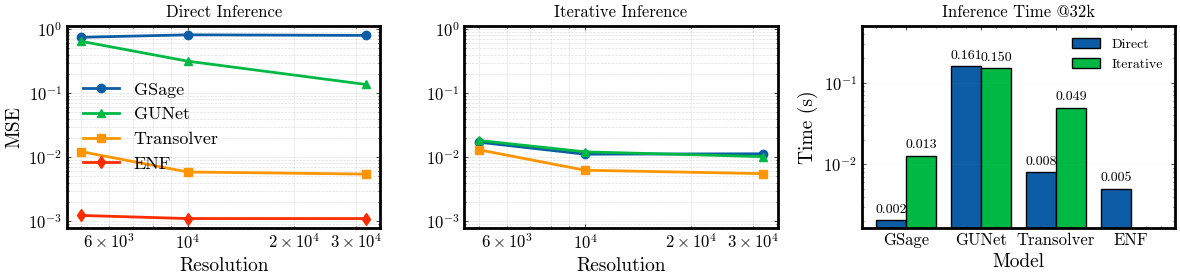

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

plt.style.use(["science", "no-latex"])
plt.rcParams.update({
    'axes.linewidth': 2,
    'lines.linewidth': 2,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.titlesize': 'large'
})

# -------------------------------------------------------
# 1. Define data for MSE plots
# -------------------------------------------------------
resolutions_gsage   = [5000, 10000, 32000]
resolutions_gunet   = [5000, 10000, 32000]  
resolutions_trans   = [5000, 10000, 32000]
resolutions_enf     = [5000, 10000, 32000]

# -- Direct Inference MSE --
mse_direct_gsage    = [0.74494, 0.81341, 0.79674]
mse_direct_gunet    = [0.64430, 0.31562, 0.13651]
mse_direct_trans    = [0.01219, 0.00587, 0.00544]
mse_direct_enf      = [0.00123,  0.0011,  0.0011]

# -- Iterative Inference MSE --
mse_iter_gsage      = [0.01716, 0.01113, 0.01129]
mse_iter_gunet      = [0.01823, 0.01211, 0.01019]
mse_iter_trans      = [0.01305, 0.00625, 0.00553]
# ENF does not have iterative inference

# -------------------------------------------------------
# 2. Define data for inference time histogram (example at resolution=32k)
# -------------------------------------------------------
models = ["GSage", "GUNet", "Transolver", "ENF"]  # Renamed GraphSAGE->GSage, GraphUNet->GUNet
time_direct_32k = [0.00206, 0.16050, 0.00800, 0.00500]  # Example direct times at 32k
time_iter_32k   = [0.01272, 0.15043, 0.04934, np.nan]   # ENF iterative => np.nan

# -------------------------------------------------------
# 3. Create the figure and subplots
#    We use a 1x3 layout: [ MSE (Direct) | MSE (Iterative) | Time Histogram ]
# -------------------------------------------------------
fig, (ax_direct, ax_iter, ax_time) = plt.subplots(1, 3, figsize=(12, 3), sharey=False)

# -------------------------------------------------------
# Subplot (A): Direct Inference MSE
# -------------------------------------------------------
ax_direct.set_title("Direct Inference")
ax_direct.set_xlabel("Resolution")
ax_direct.set_ylabel("MSE")  # Only here for the 1st subplot

# Plot for each method
line_gsage, = ax_direct.plot(resolutions_gsage, mse_direct_gsage, marker='o', label='GSage')
line_gunet, = ax_direct.plot(resolutions_gunet, mse_direct_gunet, marker='^', label='GUNet')
line_trans, = ax_direct.plot(resolutions_trans, mse_direct_trans, marker='s', label='Transolver')
line_enf,   = ax_direct.plot(resolutions_enf,   mse_direct_enf,   marker='d', label='ENF')

ax_direct.set_xscale('log')
ax_direct.set_yscale('log')
ax_direct.grid(True, which='both', linestyle='--', alpha=0.4)
ax_direct.legend(fontsize=13)  # Single legend for both MSE plots

# -------------------------------------------------------
# Subplot (B): Iterative Inference MSE
# -------------------------------------------------------
ax_iter.set_title("Iterative Inference")
ax_iter.set_xlabel("Resolution")
# We do NOT set ax_iter.set_ylabel, because we only want one MSE label on the left.

ax_iter.plot(resolutions_gsage, mse_iter_gsage, marker='o', label='GSage')
ax_iter.plot(resolutions_gunet, mse_iter_gunet, marker='^', label='GUNet')
ax_iter.plot(resolutions_trans, mse_iter_trans, marker='s', label='Transolver')
# ENF omitted (no iterative data)

ax_iter.set_xscale('log')
ax_iter.set_yscale('log')
ax_iter.grid(True, which='both', linestyle='--', alpha=0.4)

# -------------------------------------------------------
# Equalize the y-axis range of the two MSE subplots (if desired)
# -------------------------------------------------------
min_mse = min(ax_direct.get_ylim()[0], ax_iter.get_ylim()[0])
max_mse = max(ax_direct.get_ylim()[1], ax_iter.get_ylim()[1])
ax_direct.set_ylim(min_mse, max_mse)
ax_iter.set_ylim(min_mse, max_mse)

# -------------------------------------------------------
# Subplot (C): Inference Time Histogram at 32k
# -------------------------------------------------------
ax_time.set_title("Inference Time @32k")
ax_time.set_xlabel("Model")
ax_time.set_ylabel("Time (s)")

x_indices = np.arange(len(models))  # e.g., [0,1,2,3]
width = 0.4  # width of each bar

# Separate direct vs. iterative times
direct_times = np.array(time_direct_32k)
iter_times   = np.array(time_iter_32k)

bar_direct = ax_time.bar(
    x_indices - width/2, 
    direct_times, 
    width,
    label="Direct",
    color="C0",
    edgecolor="black"
)

bar_iter = ax_time.bar(
    x_indices + width/2,
    np.nan_to_num(iter_times, nan=0.0),
    width,
    label="Iterative",
    color="C1",
    edgecolor="black"
)

ax_time.set_xticks(x_indices)
ax_time.set_xticklabels(models, rotation=0)

# Optionally set a manual y-limit for clarity
# Increase the upper limit slightly above the tallest bar
current_ymax = ax_time.get_ylim()[1]  # e.g., double the max for more headroom

ax_time.set_yscale('log')
ax_time.set_ylim(top=0.5)
ax_time.legend()
ax_time.grid(True, axis='y', linestyle='--', alpha=0.1)

# Optionally, annotate the bars with actual numeric values
for rect, val in zip(bar_direct, direct_times):
    if not np.isnan(val):
        height = rect.get_height()
        ax_time.annotate(f"{val:.3f}",
                         xy=(rect.get_x() + rect.get_width()/2, height),
                         xytext=(0, 3),  # offset
                         textcoords="offset points",
                         ha='center', va='bottom')

for rect, val in zip(bar_iter, iter_times):
    if not np.isnan(val):
        height = rect.get_height()
        ax_time.annotate(f"{val:.3f}",
                         xy=(rect.get_x() + rect.get_width()/2, height),
                         xytext=(0, 3),
                         textcoords="offset points",
                         ha='center', va='bottom')

plt.tight_layout()

# -------------------------------------------------------
# 4. Save to PDF
# -------------------------------------------------------
plt.savefig("/home/dmsm/gi.catalani/Projects/enf-torch/enf-torch-main/airfrans/experiments/training/training_result_20250618-175419/plots/resolution_analysis.pdf", format="pdf", bbox_inches="tight")
plt.show()

